# Shor's Algorithm
### Factoring integers in polynomial time with a quantum computer

**Course:** UCL Quantum Computing · **Prerequisites:** QFT, phase estimation, modular arithmetic

---

## Why Factoring Matters

Integer factorisation is the mathematical backbone of RSA encryption, Diffie-Hellman, and elliptic curve cryptography — together securing essentially all encrypted internet traffic. The best classical algorithm (General Number Field Sieve) factors an $n$-bit number in:

$$\text{Classical: } \exp\!\left(O\!\left(n^{1/3}(\log n)^{2/3}\right)\right) \quad \text{(sub-exponential, super-polynomial)}$$

**Shor's algorithm (1994)** factors in:

$$\text{Quantum: } O(n^3) \quad \text{(polynomial!)}$$

This is an **exponential speedup** — the most powerful quantum advantage known for a practical problem.


## Reduction: Factoring → Period Finding

Shor's insight: factoring reduces to finding the **period** of a modular function. Given $N$ to factor:

1. Choose a random $a$ with $\gcd(a, N) = 1$ (coprime). If $\gcd(a, N) > 1$, we found a factor trivially.
2. Consider $f(x) = a^x \bmod N$. This function is **periodic** with some period $r$:
   $f(x+r) = f(x)$ because $a^r \equiv 1 \pmod{N}$.
3. If $r$ is even and $a^{r/2} \not\equiv -1 \pmod{N}$, then:
   $a^r - 1 \equiv 0 \pmod{N}$
   $(a^{r/2} - 1)(a^{r/2} + 1) \equiv 0 \pmod{N}$
   The factors of $N$ divide these two terms:
   $$p = \gcd(a^{r/2} - 1,\, N), \qquad q = \gcd(a^{r/2} + 1,\, N)$$

4. **Period finding is done quantumly** using the Quantum Fourier Transform — the classical step is just GCD.

**Example: $N = 15, a = 7$**
$7^1=7,\; 7^2=4,\; 7^3=13,\; 7^4=1 \pmod{15}$ → period $r = 4$
$\gcd(7^2-1, 15) = \gcd(48, 15) = 3$ ✓
$\gcd(7^2+1, 15) = \gcd(50, 15) = 5$ ✓


## The Quantum Fourier Transform

The QFT is the quantum analogue of the discrete Fourier transform. On $n$ qubits it maps:

$$\text{QFT}|j\rangle = \frac{1}{\sqrt{2^n}}\sum_{k=0}^{2^n-1} e^{2\pi i jk/2^n}|k\rangle$$

The circuit uses $n$ Hadamard gates and $O(n^2)$ controlled phase rotations:

$$R_k = \begin{pmatrix}1 & 0 \\ 0 & e^{2\pi i/2^k}\end{pmatrix}$$

Applied to qubit $j$: apply $H$, then controlled-$R_2, R_3, \ldots, R_{n-j}$ from higher qubits, then swap to reverse bit order.
Total circuit depth: $O(n^2)$ gates vs. classical FFT's $O(n \cdot 2^n)$.


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from math import gcd, pi
from fractions import Fraction

matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})
simulator = AerSimulator()
print("Ready ✓")


Ready ✓


In [2]:
# ── Quantum Fourier Transform ────────────────────────────────────────
def qft(n):
    """
    QFT on n qubits.
    Produces the circuit WITHOUT the final swap (swap added separately).
    """
    qc = QuantumCircuit(n, name="QFT")

    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            angle = 2 * pi / 2 ** (k - j + 1)
            qc.cp(angle, k, j)      # controlled phase rotation

    # Bit reversal: swap pairs to match DFT ordering
    for i in range(n // 2):
        qc.swap(i, n - i - 1)

    return qc

def inverse_qft(n):
    """Inverse QFT = QFT†"""
    return qft(n).inverse()

# Display the 4-qubit QFT circuit
print("4-qubit QFT circuit:")
print(qft(4).draw('text'))


4-qubit QFT circuit:
     ┌───┐                                                                     »
q_0: ┤ H ├─■────────■─────────────■────────────────────────────────────────────»
     └───┘ │P(π/2)  │       ┌───┐ │                                            »
q_1: ──────■────────┼───────┤ H ├─┼────────■────────■───────────────────────X──»
                    │P(π/4) └───┘ │        │P(π/2)  │       ┌───┐           │  »
q_2: ───────────────■─────────────┼────────■────────┼───────┤ H ├─■─────────X──»
                                  │P(π/8)           │P(π/4) └───┘ │P(π/2) ┌───┐»
q_3: ─────────────────────────────■─────────────────■─────────────■───────┤ H ├»
                                                                          └───┘»
«        
«q_0: ─X─
«      │ 
«q_1: ─┼─
«      │ 
«q_2: ─┼─
«      │ 
«q_3: ─X─
«        


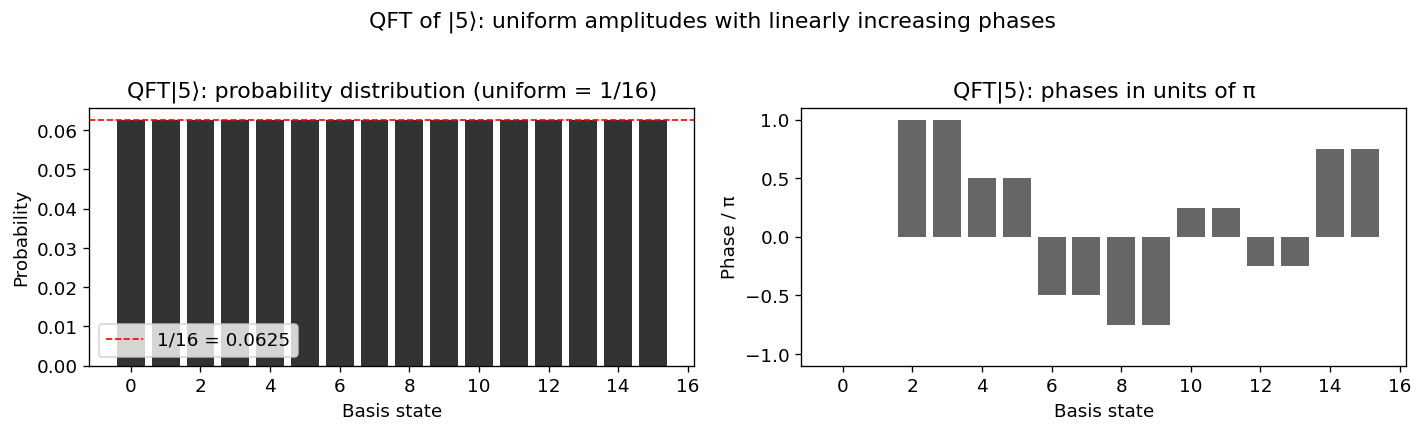


QFT of any basis state |j⟩:
  All amplitudes are equal: |amplitude|² = 1/N (uniform distribution)
  Phases rotate at frequency j: φ_k = 2π·j·k/N


In [3]:
# ── Verify QFT: transform a basis state ─────────────────────────────
# QFT|j⟩ should produce phases exp(2πi·j·k/N) on each basis state |k⟩
n = 4
N = 2**n

# Build circuit: prepare |5⟩ = |0101⟩, then apply QFT
qc_verify = QuantumCircuit(n)
for i, bit in enumerate(reversed(format(5, f'0{n}b'))):
    if bit == '1':
        qc_verify.x(i)
qc_verify.compose(qft(n), inplace=True)

sv = Statevector(qc_verify)
probs = np.abs(sv.data) ** 2
phases = np.angle(sv.data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

ax1.bar(range(N), probs, color='#333')
ax1.set_title(f"QFT|5⟩: probability distribution (uniform = 1/{N})")
ax1.set_xlabel("Basis state")
ax1.set_ylabel("Probability")
ax1.axhline(1/N, color='red', ls='--', lw=1, label=f"1/{N} = {1/N:.4f}")
ax1.legend()

ax2.bar(range(N), phases / pi, color='#666')
ax2.set_title("QFT|5⟩: phases in units of π")
ax2.set_xlabel("Basis state")
ax2.set_ylabel("Phase / π")
ax2.set_ylim(-1.1, 1.1)

plt.suptitle("QFT of |5⟩: uniform amplitudes with linearly increasing phases", y=1.02)
plt.tight_layout()
plt.savefig('qft_demo.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nQFT of any basis state |j⟩:")
print("  All amplitudes are equal: |amplitude|² = 1/N (uniform distribution)")
print("  Phases rotate at frequency j: φ_k = 2π·j·k/N")


In [4]:
# ── Quantum Phase Estimation ─────────────────────────────────────────
# QPE estimates the phase φ in U|ψ⟩ = e^{2πiφ}|ψ⟩
# This is the subroutine Shor's uses to find the period.

def qpe_circuit(eigenphase, n_count=4):
    """
    Simplified QPE: demonstrate phase estimation for a single-qubit unitary
    U = phase gate with eigenphase φ.
    n_count: number of counting qubits.
    """
    qc = QuantumCircuit(n_count + 1, n_count)

    # Prepare eigenstate |1⟩ of U (phase gate fixes |1⟩)
    qc.x(n_count)

    # Superposition on counting qubits
    qc.h(range(n_count))

    # Apply controlled-U^(2^j) for each counting qubit
    for j in range(n_count):
        repetitions = 2 ** j
        angle = 2 * pi * eigenphase * repetitions
        qc.cp(angle, j, n_count)   # controlled phase = controlled-U^(2^j)

    # Inverse QFT on counting register
    qc.compose(inverse_qft(n_count), range(n_count), inplace=True)

    # Measure
    qc.measure(range(n_count), range(n_count))
    return qc

# Test: estimate phase φ = 1/4 → should measure |0100⟩ (= 4 in decimal, 4/16 = 1/4) ✓
phi = 1/4
n_count = 4
qc_qpe = qpe_circuit(phi, n_count)

t_qc = transpile(qc_qpe, simulator)
result = simulator.run(t_qc, shots=2048).result()
counts = result.get_counts()

print(f"QPE for phase φ = {phi}")
print(f"Expected measurement: {int(phi * 2**n_count)} = |{format(int(phi * 2**n_count), f'0{n_count}b')}⟩")
print(f"Measured: {counts}")
print(f"\nEstimated phase: {max(counts, key=counts.get)} / 2^{n_count} = {int(max(counts, key=counts.get), 2)/2**n_count}")


QPE for phase φ = 0.25
Expected measurement: 4 = |0100⟩
Measured: {'1110': 17, '1010': 24, '1001': 18, '0101': 79, '1111': 405, '1101': 22, '1011': 46, '0111': 433, '1100': 56, '0100': 441, '0110': 79, '1000': 428}

Estimated phase: 0100 / 2^4 = 0.25


## Shor's Algorithm for N = 15

We now implement the full algorithm for $N=15$, $a=7$.

**Circuit structure:**
1. $n_{\text{count}}$ counting qubits in superposition $\to$ will hold the period information
2. 4 work qubits initialised to $|1\rangle$ (the state that gets multiplied)
3. Apply controlled-$U^{2^j}$ for each counting qubit, where $U|y\rangle = |ay \bmod 15\rangle$
4. Apply inverse QFT to counting register
5. Measure counting register — outcomes cluster at multiples of $2^{n_{\text{count}}}/r$
6. Extract $r$ using continued fractions, then compute GCD for the factors

The controlled modular multiplication $U|y\rangle = |7y \bmod 15\rangle$ is implemented with SWAP gates — the 4-qubit cyclic permutation $1 \to 7 \to 4 \to 13 \to 1$ can be decomposed into SWAPs and X gates.


In [5]:
# ── Controlled modular multiplication for N = 15 ─────────────────────
def c_amod15(a, power):
    """
    Controlled-U^power where U|y⟩ = |a·y mod 15⟩ on 4 work qubits.
    Implements the cycle 1 → a → a² → ... (mod 15) using SWAP/X decomposition.
    Only supports a coprime to 15: {2, 4, 7, 8, 11, 13}.
    """
    if a not in [2, 4, 7, 8, 11, 13]:
        raise ValueError(f"a={a} must be coprime to 15. Choose from {{2,4,7,8,11,13}}.")

    U = QuantumCircuit(4)
    for _ in range(power):
        # SWAP decomposition of the cyclic permutation induced by ×a mod 15
        if a in [2, 13]:
            U.swap(0, 1); U.swap(1, 2); U.swap(2, 3)
        if a in [7, 8]:
            U.swap(2, 3); U.swap(1, 2); U.swap(0, 1)
        if a in [4, 11]:
            U.swap(1, 3); U.swap(0, 2)
        if a in [7, 11, 13]:
            for q in range(4):
                U.x(q)

    gate = U.to_gate()
    gate.name = f"{a}^{power} mod 15"
    return gate.control()          # make it a controlled gate

# Verify: 7^1 mod 15 = 7, 7^2 = 4, 7^3 = 13, 7^4 = 1 → period r = 4
a = 7
print(f"Verifying a={a} mod 15 cycle:")
val = 1
for k in range(1, 6):
    val = (val * a) % 15
    print(f"  {a}^{k} mod 15 = {val}")
print(f"  Period r = 4  (7^4 mod 15 = 1) ✓")


Verifying a=7 mod 15 cycle:
  7^1 mod 15 = 7
  7^2 mod 15 = 4
  7^3 mod 15 = 13
  7^4 mod 15 = 1
  7^5 mod 15 = 7
  Period r = 4  (7^4 mod 15 = 1) ✓


In [6]:
# ── Full Shor's Circuit for N = 15 ──────────────────────────────────
def shors_circuit(a, N=15, n_count=8):
    """
    Build Shor's period-finding circuit for N=15.
    a: base (coprime to 15)
    n_count: counting qubits (more → sharper peaks, easier phase readout)
    """
    n_work = 4          # work register: 4 qubits to represent 0-15
    qc = QuantumCircuit(n_count + n_work, n_count)

    # ① Initialise work register to |1⟩ = |0001⟩
    qc.x(n_count)       # qubit n_count is the LSB of the work register

    # ② Uniform superposition on counting register
    qc.h(range(n_count))
    qc.barrier()

    # ③ Controlled-U^(2^j) for j = 0, 1, ..., n_count-1
    for j in range(n_count):
        qc.append(
            c_amod15(a, 2**j),
            [j] + list(range(n_count, n_count + n_work))
        )
    qc.barrier()

    # ④ Inverse QFT on counting register → transforms phases to measurable state
    qc.compose(inverse_qft(n_count), range(n_count), inplace=True)
    qc.barrier()

    # ⑤ Measure counting register
    qc.measure(range(n_count), range(n_count))
    return qc

a = 7
qc_shor = shors_circuit(a, N=15, n_count=8)
print(f"Shor's circuit for N=15, a={a}:")
print(f"  Total qubits: {qc_shor.num_qubits}")
print(f"  Total classical bits: {qc_shor.num_clbits}")
print(f"  Circuit depth: {qc_shor.depth()}")
print(f"  Gate count: {qc_shor.size()}")


Shor's circuit for N=15, a=7:
  Total qubits: 12
  Total classical bits: 8
  Circuit depth: 26
  Gate count: 65


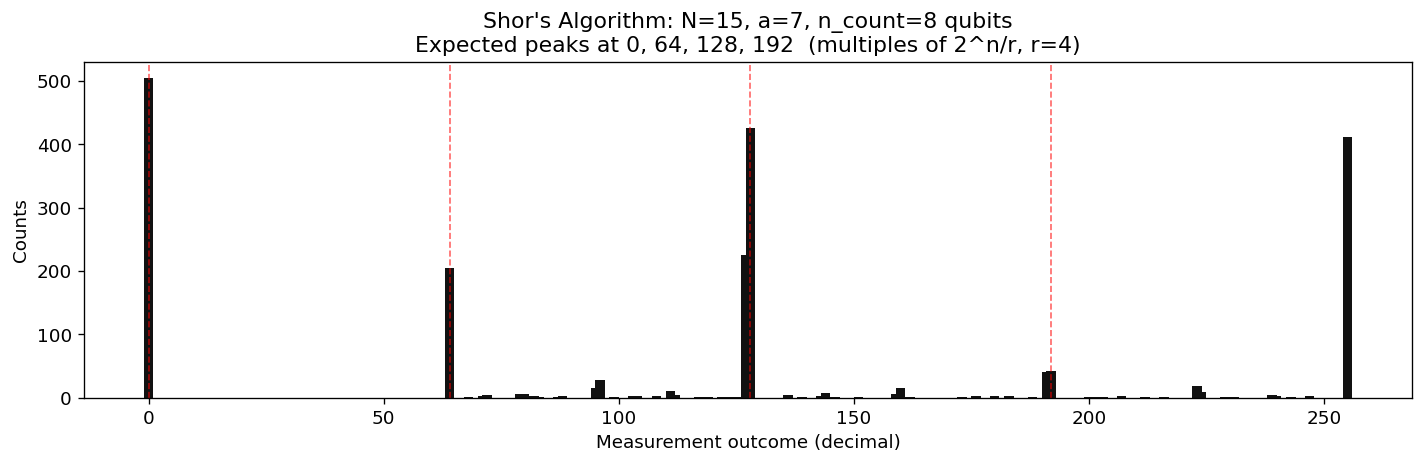


Top measurement outcomes:
      Binary  Decimal    Phase = k/256     Fraction   Counts
--------------------------------------------------------------
    00000000        0           0.0000            0      505
    10000000      128           0.5000          1/2      426
    11111111      255           0.9961            1      412
    01111111      127           0.4961          1/2      226
    01000000       64           0.2500          1/4      204
    11000000      192           0.7500          3/4       42
    10111111      191           0.7461          3/4       41
    01100000       96           0.3750          3/8       28


In [7]:
# ── Run the circuit ─────────────────────────────────────────────────
a, n_count = 7, 8
N_val = 15
qc_shor = shors_circuit(a, N=N_val, n_count=n_count)

t_qc = transpile(qc_shor, simulator)
result = simulator.run(t_qc, shots=2048).result()
counts = result.get_counts()

# Plot histogram — expect peaks at 0, 64, 128, 192  (= 0, 256/4, 256/2, 3·256/4)
fig, ax = plt.subplots(figsize=(12, 4))
sorted_counts = dict(sorted(counts.items(), key=lambda x: int(x[0], 2)))
states = [int(k, 2) for k in sorted_counts.keys()]
vals = list(sorted_counts.values())
ax.bar(states, vals, color='#111', width=2)
ax.set_xlabel("Measurement outcome (decimal)")
ax.set_ylabel("Counts")
ax.set_title(f"Shor's Algorithm: N=15, a={a}, n_count={n_count} qubits\n"
             f"Expected peaks at 0, {2**n_count//4}, {2**n_count//2}, {3*2**n_count//4}  (multiples of 2^n/r, r=4)")
for x in [0, 2**n_count//4, 2**n_count//2, 3*2**n_count//4]:
    ax.axvline(x, color='red', lw=1, ls='--', alpha=0.6)
plt.tight_layout()
plt.savefig('shors_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

# Show top outcomes
top = sorted(counts.items(), key=lambda x: -x[1])[:8]
print("\nTop measurement outcomes:")
print(f"{'Binary':>12} {'Decimal':>8} {'Phase = k/256':>16} {'Fraction':>12} {'Counts':>8}")
print("-" * 62)
for bits, cnt in top:
    dec = int(bits, 2)
    phase = dec / 2**n_count
    frac = Fraction(phase).limit_denominator(N_val)
    print(f"{bits:>12} {dec:>8} {phase:>16.4f} {str(frac):>12} {cnt:>8}")


In [8]:
# ── Classical post-processing: extract period → factors ──────────────
print(f"Extracting period r from measurement outcomes for N=15, a={a}")
print("=" * 60)

a = 7
N_val = 15
n_count = 8

# Get the most frequent non-zero measurement
top = sorted(
    [(int(k, 2), v) for k, v in counts.items() if int(k, 2) != 0],
    key=lambda x: -x[1]
)

found_factors = set()
for dec, cnt in top[:6]:
    phase = dec / 2**n_count
    # Continued fraction approximation to get r
    frac = Fraction(phase).limit_denominator(N_val)
    r = frac.denominator

    print(f"\nOutcome {dec:3d} → phase = {dec}/{2**n_count} ≈ {phase:.4f} → fraction {frac} → r = {r}")

    if r % 2 != 0:
        print(f"  r={r} is odd — skip")
        continue

    # Try to extract factors
    guess1 = gcd(a**(r//2) - 1, N_val)
    guess2 = gcd(a**(r//2) + 1, N_val)
    print(f"  gcd({a}^{r//2} - 1, {N_val}) = gcd({a**(r//2)-1}, {N_val}) = {guess1}")
    print(f"  gcd({a}^{r//2} + 1, {N_val}) = gcd({a**(r//2)+1}, {N_val}) = {guess2}")

    for g in [guess1, guess2]:
        if 1 < g < N_val:
            found_factors.add(g)

print("\n" + "=" * 60)
if found_factors:
    factors = sorted(found_factors)
    print(f"\n✓ Factors of {N_val}: {factors[0]} × {N_val // factors[0]} = {N_val}")
    assert factors[0] * (N_val // factors[0]) == N_val
else:
    print("No factors found in top outcomes — re-run with more shots or different a")


Extracting period r from measurement outcomes for N=15, a=7

Outcome 128 → phase = 128/256 ≈ 0.5000 → fraction 1/2 → r = 2
  gcd(7^1 - 1, 15) = gcd(6, 15) = 3
  gcd(7^1 + 1, 15) = gcd(8, 15) = 1

Outcome 255 → phase = 255/256 ≈ 0.9961 → fraction 1 → r = 1
  r=1 is odd — skip

Outcome 127 → phase = 127/256 ≈ 0.4961 → fraction 1/2 → r = 2
  gcd(7^1 - 1, 15) = gcd(6, 15) = 3
  gcd(7^1 + 1, 15) = gcd(8, 15) = 1

Outcome  64 → phase = 64/256 ≈ 0.2500 → fraction 1/4 → r = 4
  gcd(7^2 - 1, 15) = gcd(48, 15) = 3
  gcd(7^2 + 1, 15) = gcd(50, 15) = 5

Outcome 192 → phase = 192/256 ≈ 0.7500 → fraction 3/4 → r = 4
  gcd(7^2 - 1, 15) = gcd(48, 15) = 3
  gcd(7^2 + 1, 15) = gcd(50, 15) = 5

Outcome 191 → phase = 191/256 ≈ 0.7461 → fraction 3/4 → r = 4
  gcd(7^2 - 1, 15) = gcd(48, 15) = 3
  gcd(7^2 + 1, 15) = gcd(50, 15) = 5


✓ Factors of 15: 3 × 5 = 15


In [9]:
# ── Summary: classical vs quantum scaling ───────────────────────────
print("Factoring complexity comparison")
print("=" * 65)
print(f"{'Bits n':>8} | {'RSA key size':>14} | {'Classical GNFS':>22} | {'Shor O(n³)':>12}")
print("-" * 65)

for n in [128, 256, 512, 1024, 2048, 4096]:
    # Classical GNFS: rough order-of-magnitude (ignoring constants)
    gnfs_exp = (64/9)**(1/3) * n**(1/3) * (np.log2(n))**(2/3)
    gnfs = f"~2^{gnfs_exp:.0f}"
    shor = f"~{n**3:,.0f} gates"
    rsa = f"RSA-{n}"
    print(f"{n:>8} | {rsa:>14} | {gnfs:>22} | {shor:>12}")

print("\nWith physical quantum computers of ~4,000 logical qubits,")
print("Shor's algorithm would break RSA-2048 in hours.")
print("Current quantum computers (2024): ~1000 noisy physical qubits,")
print("~100-200 logical qubits — not yet a threat, but approaching rapidly.")


Factoring complexity comparison
  Bits n |   RSA key size |         Classical GNFS |   Shor O(n³)
-----------------------------------------------------------------
     128 |        RSA-128 |                  ~2^35 | ~2,097,152 gates
     256 |        RSA-256 |                  ~2^49 | ~16,777,216 gates
     512 |        RSA-512 |                  ~2^67 | ~134,217,728 gates
    1024 |       RSA-1024 |                  ~2^90 | ~1,073,741,824 gates
    2048 |       RSA-2048 |                 ~2^121 | ~8,589,934,592 gates
    4096 |       RSA-4096 |                 ~2^161 | ~68,719,476,736 gates

With physical quantum computers of ~4,000 logical qubits,
Shor's algorithm would break RSA-2048 in hours.
Current quantum computers (2024): ~1000 noisy physical qubits,
~100-200 logical qubits — not yet a threat, but approaching rapidly.


## Key Takeaways

1. **Period finding is the key**: Shor reduces factoring to finding the period $r$ of $f(x) = a^x \bmod N$. The quantum computer does only this step; everything else is classical number theory.

2. **QFT is the engine**: The inverse QFT at the end of the circuit maps the periodic phase pattern in the counting register into sharp peaks at multiples of $2^{n_{\text{count}}}/r$. Measuring these peaks reveals $r$.

3. **Continued fractions extract $r$**: The measurement outcome is a rational multiple of $2^{n_{\text{count}}}$ close to $k/r$. Continued fractions convert this to the exact fraction $k/r$ in lowest terms, giving $r$ as the denominator.

4. **Exponential speedup**: $O(e^{n^{1/3}})$ classical → $O(n^3)$ quantum. For 2048-bit RSA keys, this is the difference between $10^{50}$ operations and $10^{10}$ operations.

5. **The quantum advantage is structural**: Shor's algorithm exploits the exponential state space of quantum registers to perform modular exponentiation over all $2^{n_{\text{count}}}$ inputs simultaneously, then uses interference (via QFT) to extract the globally periodic structure.

6. **Real hardware requirements**: Factoring RSA-2048 requires ~4,000 **logical** qubits (error-corrected). With current physical error rates (~0.1%), this needs ~4 million physical qubits. IBM Q plans to reach this scale in the early 2030s.
